# Import libraries

In [64]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style("darkgrid")

# Load data

## Seattle, Washington data

In [3]:
df_sea = pd.read_csv("../data/seattle_rain.csv")
df_pwm = pd.read_csv("../data/portland_rain.csv")

print("Seattle Rain Data:")
print(df_sea.head())

print("Portland Rain Data:")
print(df_pwm.head())

Seattle Rain Data:
       STATION                    NAME    DATE  DAPR  MDPR  PRCP  SNOW  SNWD  \
0  US1WAKG0225  SEATTLE 2.1 ESE, WA US  1/1/18   NaN   NaN  0.00   NaN   NaN   
1  US1WAKG0225  SEATTLE 2.1 ESE, WA US  1/2/18   NaN   NaN  0.00   NaN   NaN   
2  US1WAKG0225  SEATTLE 2.1 ESE, WA US  1/3/18   NaN   NaN  0.00   NaN   NaN   
3  US1WAKG0225  SEATTLE 2.1 ESE, WA US  1/4/18   NaN   NaN  0.00   NaN   NaN   
4  US1WAKG0225  SEATTLE 2.1 ESE, WA US  1/5/18   NaN   NaN  0.25   NaN   NaN   

   WESD  WESF  
0   NaN   NaN  
1   NaN   NaN  
2   NaN   NaN  
3   NaN   NaN  
4   NaN   NaN  
Portland Rain Data:
       STATION                     NAME        DATE  PRCP  SNOW  SNWD
0  USW00014764  PORTLAND JETPORT, ME US  2018-01-01  0.00   0.0   9.1
1  USW00014764  PORTLAND JETPORT, ME US  2018-01-02  0.00   0.0   9.1
2  USW00014764  PORTLAND JETPORT, ME US  2018-01-03  0.00   0.0   7.9
3  USW00014764  PORTLAND JETPORT, ME US  2018-01-04  0.62  11.9   7.9
4  USW00014764  PORTLAND JETPORT, 

## Portland, Maine data

# Data checking

## Seattle, WA

In [4]:
df_sea.info()
print()

print("# Unique Stations:", df_sea['STATION'].nunique())
print()

print(df_sea['DATE'].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB

# Unique Stations: 1

object


In [5]:
df_sea['DATE'] = pd.to_datetime(df_sea['DATE'])

#df_sea.info()

print("SEA Min Date:", df_sea['DATE'].min())
print()

print("SEA Max Date", df_sea['DATE'].max())

SEA Min Date: 2018-01-01 00:00:00

SEA Max Date 2022-12-31 00:00:00


C:\Users\Travis\AppData\Local\Temp\ipykernel_24100\1418163568.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sea['DATE'] = pd.to_datetime(df_sea['DATE'])


## Portland, ME

In [6]:
df_pwm.info()
print()

print("# Unique Stations:", df_pwm['STATION'].nunique())
print()

print(df_pwm['DATE'].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   object 
 1   NAME     1826 non-null   object 
 2   DATE     1826 non-null   object 
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), object(3)
memory usage: 85.7+ KB

# Unique Stations: 1

object


In [7]:
df_pwm['DATE'] = pd.to_datetime(df_pwm['DATE'])

#df_pwm.info()

print("PWM Min Date:", df_pwm['DATE'].min())
print()

print("PWM Max Date", df_pwm['DATE'].max())

PWM Min Date: 2018-01-01 00:00:00

PWM Max Date 2022-12-31 00:00:00


# Data processing

## Joining Dataframes

In [8]:
df = df_sea[['DATE', 'PRCP']].merge(df_pwm[['DATE', 'PRCP']], on = 'DATE', how = 'outer')

print(df.head()) # PRCP_x is SEA, PRCP_y is PWM
print("Shape: ", df.shape)

        DATE  PRCP_x  PRCP_y
0 2018-01-01    0.00    0.00
1 2018-01-02    0.00    0.00
2 2018-01-03    0.00    0.00
3 2018-01-04    0.00    0.62
4 2018-01-05    0.25    0.01
Shape:  (1826, 3)


In [9]:
df = pd.melt(df, id_vars = 'DATE', var_name = 'city', value_name = 'precipitation')

print(df.head())
print()

print(df.tail())

        DATE    city  precipitation
0 2018-01-01  PRCP_x           0.00
1 2018-01-02  PRCP_x           0.00
2 2018-01-03  PRCP_x           0.00
3 2018-01-04  PRCP_x           0.00
4 2018-01-05  PRCP_x           0.25

           DATE    city  precipitation
3647 2022-12-27  PRCP_y           0.00
3648 2022-12-28  PRCP_y           0.01
3649 2022-12-29  PRCP_y           0.00
3650 2022-12-30  PRCP_y           0.00
3651 2022-12-31  PRCP_y           0.05


## Cleaning

In [10]:
df.loc[df['city'] == 'PRCP_x', 'city'] = 'SEA'
df.loc[df['city'] == 'PRCP_y', 'city'] = 'PWM'

print(df.head())
print()

print(df.tail())

        DATE city  precipitation
0 2018-01-01  SEA           0.00
1 2018-01-02  SEA           0.00
2 2018-01-03  SEA           0.00
3 2018-01-04  SEA           0.00
4 2018-01-05  SEA           0.25

           DATE city  precipitation
3647 2022-12-27  PWM           0.00
3648 2022-12-28  PWM           0.01
3649 2022-12-29  PWM           0.00
3650 2022-12-30  PWM           0.00
3651 2022-12-31  PWM           0.05


In [11]:
df = df.rename(columns = {'DATE': 'date'})

print(df.head())
print()

print(df.tail())

        date city  precipitation
0 2018-01-01  SEA           0.00
1 2018-01-02  SEA           0.00
2 2018-01-03  SEA           0.00
3 2018-01-04  SEA           0.00
4 2018-01-05  SEA           0.25

           date city  precipitation
3647 2022-12-27  PWM           0.00
3648 2022-12-28  PWM           0.01
3649 2022-12-29  PWM           0.00
3650 2022-12-30  PWM           0.00
3651 2022-12-31  PWM           0.05


### Handling missing values

In [12]:
df.info()
print()

print("Seattle NaN:", df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum())
print("Portland NaN:", df.loc[df['city'] == 'PWM', 'precipitation'].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB

Seattle NaN: 190
Portland NaN: 0


In [16]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

print(df.head())

        date city  precipitation  day_of_year
0 2018-01-01  SEA           0.00            1
1 2018-01-02  SEA           0.00            2
2 2018-01-03  SEA           0.00            3
3 2018-01-04  SEA           0.00            4
4 2018-01-05  SEA           0.25            5


In [17]:
# mean precipitation for each inidi
mean_day_precipitation = df.loc[
    df['city'] == 'SEA',
    ['precipitation', 'day_of_year']
].groupby(
    'day_of_year'
).mean()

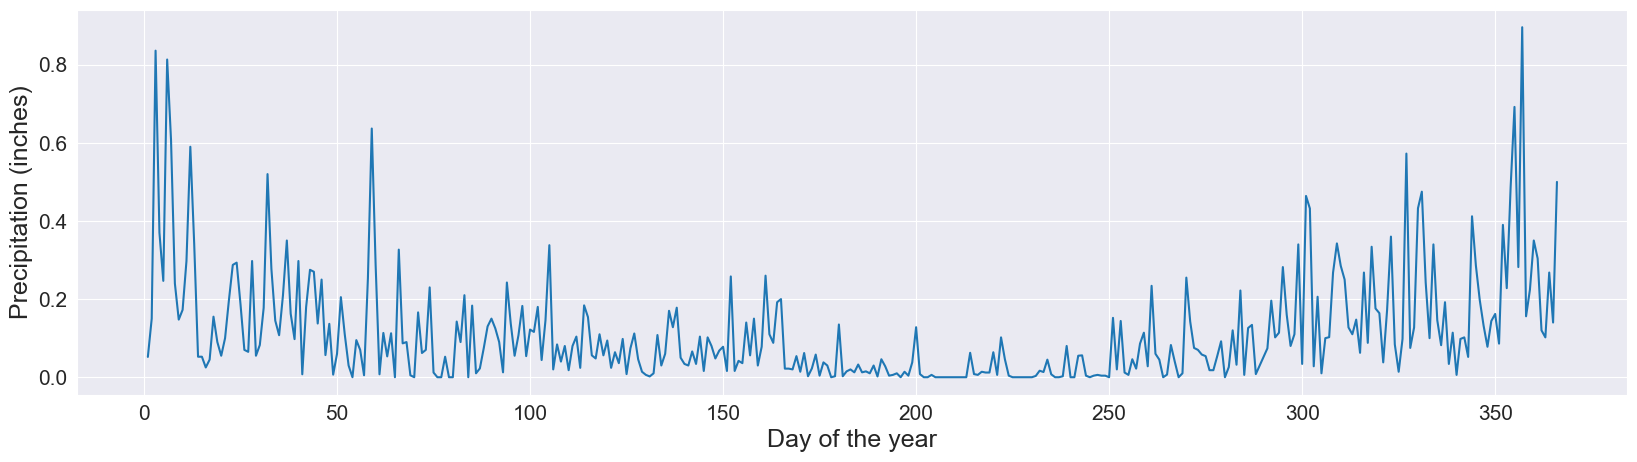

In [18]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = mean_day_precipitation, x = 'day_of_year', y = 'precipitation')

plt.xlabel('Day of the year', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

In [21]:
indices = np.where(df['precipitation'].isna() == True)[0]

#print(indices)

for index in indices:
    df.loc[index, 'precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

print(df.isna().sum())

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64


## Exporting

In [22]:
df.to_csv('clean_sea_pwm_weather.csv', encoding = 'utf-8-sig', index = False)

# Exploratory Data Analysis

## Descriptive Statistics

In [42]:
# Stats by city
print(df[['city', 'precipitation']].groupby('city').describe())

     precipitation                                               
             count      mean       std  min  25%   50%   75%  max
city                                                             
PWM         1826.0  0.130482  0.336819  0.0  0.0  0.00  0.05  3.4
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.6


In [49]:
# Cumulative Rainfall
total_rainfall = df.groupby('city')['precipitation'].sum()

print("Total Cumulative Rainfall (inches):")
print(total_rainfall)

Total Cumulative Rainfall (inches):
city
PWM    238.260000
SEA    206.831667
Name: precipitation, dtype: float64


In [59]:
# Cumulative Monthly Rainfall
monthly_total_rainfall = df.groupby(['city', 'month'])['precipitation'].sum()

print("Monthly Cumulative Rainfall:")
print()

print(monthly_total_rainfall.unstack())

Monthly Cumulative Rainfall:

month      1        2          3        4      5       6        7          8   \
city                                                                            
PWM    17.350  18.7000  15.170000  24.6800  10.42  16.110  19.2300  18.300000   
SEA    35.765  24.8825  13.806667  15.0725  10.72   9.475   2.1675   3.099167   

month         9      10     11     12  
city                                   
PWM    15.360000  30.26  27.59  25.09  
SEA     8.343333  18.36  30.28  34.86  


In [43]:
# Mean daily precipitation
print(df[['city', 'precipitation']].groupby('city').mean())

      precipitation
city               
PWM        0.130482
SEA        0.113270


In [44]:
# Precipitation by month
df['month'] = pd.DatetimeIndex(df['date']).month

print(df.head())
print()

print(df['month'].unique())

        date city  precipitation  day_of_year  month  any_precipitation
0 2018-01-01  SEA           0.00            1      1              False
1 2018-01-02  SEA           0.00            2      1              False
2 2018-01-03  SEA           0.00            3      1              False
3 2018-01-04  SEA           0.00            4      1              False
4 2018-01-05  SEA           0.25            5      1               True

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [27]:
# Mean Monthly Precipitation
print(df[['month', 'precipitation', 'city']].groupby(['city', 'month']).mean())

            precipitation
city month               
PWM  1           0.111935
     2           0.132624
     3           0.097871
     4           0.164533
     5           0.067226
     6           0.107400
     7           0.124065
     8           0.118065
     9           0.102400
     10          0.195226
     11          0.183933
     12          0.161871
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903


In [31]:
# Days with precipitation (proportion)
df['any_precipitation'] = df['precipitation'] > 0

print(df.head(10))

        date city  precipitation  day_of_year  month  any_precipitation
0 2018-01-01  SEA         0.0000            1      1              False
1 2018-01-02  SEA         0.0000            2      1              False
2 2018-01-03  SEA         0.0000            3      1              False
3 2018-01-04  SEA         0.0000            4      1              False
4 2018-01-05  SEA         0.2500            5      1               True
5 2018-01-06  SEA         0.5700            6      1               True
6 2018-01-07  SEA         0.2300            7      1               True
7 2018-01-08  SEA         0.4100            8      1               True
8 2018-01-09  SEA         0.1475            9      1               True
9 2018-01-10  SEA         0.1725           10      1               True


## Statistical Testing

In [ ]:
significance_level = 0.05
significantly_different = np.zeros(12)

for month in range(1, 13):
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    stl_data = df.loc[(df['city'] == 'PWM') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, stl_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f"  t-statistic = {t_statistic:.2f}")
    print(f"  p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
  t-statistic = 3.33
  p-value t test = 0.001
--------------------
Month 2:
  t-statistic = 1.27
  p-value t test = 0.203
--------------------
Month 3:
  t-statistic = -0.38
  p-value t test = 0.702
--------------------
Month 4:
  t-statistic = -1.82
  p-value t test = 0.070
--------------------
Month 5:
  t-statistic = 0.10
  p-value t test = 0.918
--------------------
Month 6:
  t-statistic = -1.61
  p-value t test = 0.108
--------------------
Month 7:
  t-statistic = -4.32
  p-value t test = 0.000
--------------------
Month 8:
  t-statistic = -3.60
  p-value t test = 0.000
--------------------
Month 9:
  t-statistic = -1.71
  p-value t test = 0.089
--------------------
Month 10:
  t-statistic = -1.76
  p-value t test = 0.080
--------------------
Month 11:
  t-statistic = 0.45
  p-value t test = 0.654
--------------------
Month 12:
  t-statistic = 1.38
  p-value t test = 0.168
--------------------


In [ ]:
significance_level = 0.05
significantly_different_proportion = np.zeros(12)

for month in range(1, 13):

    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )

    days_with_precipitation = contingency_table[True]

    total_counts = contingency_table.sum(axis=1)

    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}:")
    print(f"  z-statistic = {zstat:.2f}")
    print(f"  p-value = {p_value:.3f}")
    print("-" * 20)

Month 1:
  z-statistic = -7.98
  p-value = 0.000
--------------------
Month 2:
  z-statistic = -7.30
  p-value = 0.000
--------------------
Month 3:
  z-statistic = -2.53
  p-value = 0.011
--------------------
Month 4:
  z-statistic = -3.35
  p-value = 0.001
--------------------
Month 5:
  z-statistic = -2.80
  p-value = 0.005
--------------------
Month 6:
  z-statistic = -1.41
  p-value = 0.157
--------------------
Month 7:
  z-statistic = 1.88
  p-value = 0.060
--------------------
Month 8:
  z-statistic = -0.51
  p-value = 0.612
--------------------
Month 9:
  z-statistic = -1.46
  p-value = 0.144
--------------------
Month 10:
  z-statistic = -2.62
  p-value = 0.009
--------------------
Month 11:
  z-statistic = -5.93
  p-value = 0.000
--------------------
Month 12:
  z-statistic = -7.80
  p-value = 0.000
--------------------


In [66]:
contingency_table = pd.crosstab(
        df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation']
    )

contingency_table

any_precipitation,False,True
city,,
PWM,106,49
SEA,36,119


# Visualizaions TEMP

## Volume of Rain

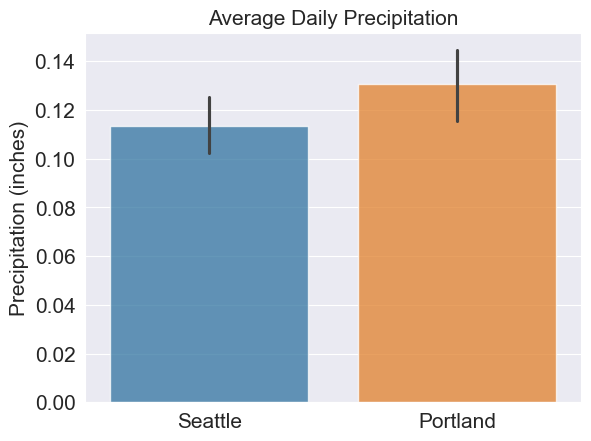

In [ ]:
# Average Daily Precipitation
sns.barplot(data = df, x = 'city', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.title('Average Daily Precipitation', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.xlabel(None)
plt.xticks([0, 1], ['Seattle', 'Portland'])
plt.tick_params(labelsize = 15)

plt.show()

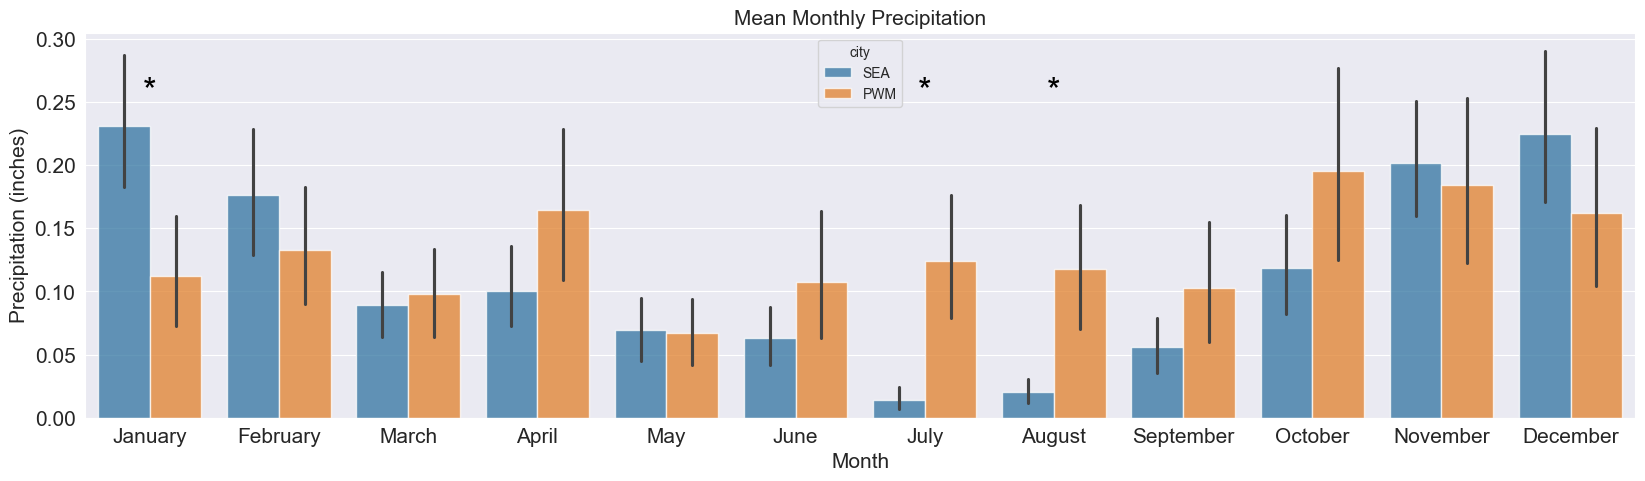

In [ ]:
# Average Monthly Precipitation
plt.figure(figsize = (20, 5))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.title('Mean Monthly Precipitation', fontsize = 15)
plt.tick_params(labelsize = 15)


import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks = range(12), labels = month_names)

# Add asterisks for significant months
for month in range(12):
    if significantly_different[month] == 1:
        # Adjust the y-position of the asterisk as needed
        y_pos = df.loc[df['month'] == month+1, 'precipitation'].max() + 0.01
        plt.text(month, 0.25, '*', ha = 'center', fontsize=25, color='black')

plt.show()

### Summary

-  

# Visualizations

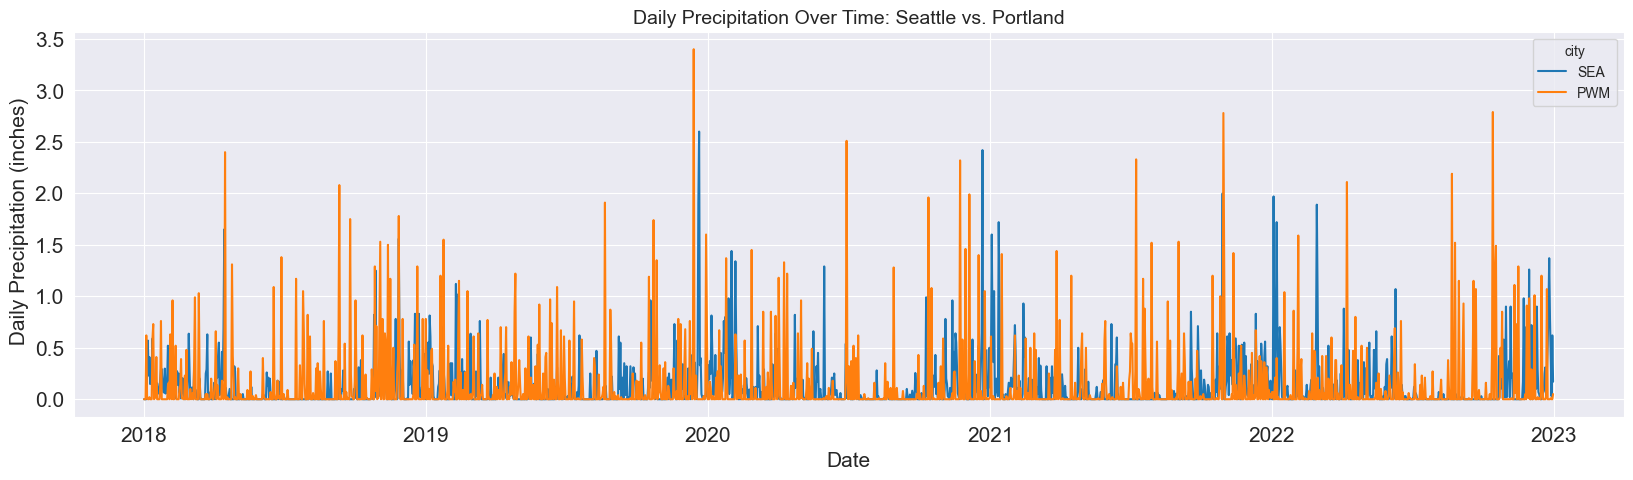

In [29]:
# Daily Precipitation Over Time: Seattle vs. Portland
plt.figure(figsize = (20, 5))

sns.lineplot(data =  df, x = 'date', y = 'precipitation', hue = 'city')

plt.title("Daily Precipitation Over Time: Seattle vs. Portland", fontsize=14)
plt.xlabel("Date", fontsize = 15)
plt.ylabel(" Daily Precipitation (inches)", fontsize = 15)

plt.tick_params(labelsize = 15)
plt.show()

In [ ]:
# Mean Daily Precipitation
sns.barplot(data = df, x = 'city', y = 'precipitation', hue = 'city')

plt.title('Mean Daily Precipitation', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.xlabel('City', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()


In [ ]:
# Precipitation by month (boxplot)
plt.figure(figsize = (20, 4))

sns.boxplot(data = df, x  = 'month', y = 'precipitation', hue = 'city')

plt.title('Precipitation by Month', fontsize = 15)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks = range(12), labels = month_names)

plt.show()

In [ ]:
# Precipitation by month (barplot)
plt.figure(figsize=(20, 4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city') 

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.xticks(ticks=range(12), labels = month_names)

plt.show()

In [ ]:
# Days with precipitation (total proportion)
sns.barplot(data = df, x = 'city', y = 'any_precipitation', errorbar = None, hue = 'city')

plt.xlabel('City', fontsize = 15)
plt.ylabel('Proportion of Days with Precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

In [ ]:
# Days with precipitation (monthly proportion)
plt.figure(figsize = (20, 4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city')

plt.xlabel(None)
plt.ylabel('Proportion of Days with Precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize = 15)

plt.show()

### Select Visualizations

In [ ]:
# Mean daily precipitation
sns.barplot(data = df, x = 'city', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.title('Mean daily precipitation', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.xlabel(None)

plt.xticks([0, 1], ['Seattle', 'Portland'])

plt.tick_params(labelsize = 15)

plt.show()



In [ ]:
# Mean monthly precipitation
plt.figure(figsize = (20, 4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.title('Mean monthly precipitation', fontsize = 15)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.xticks(ticks=range(12), labels = month_names)

plt.show()

In [ ]:
# Proportion of days with precipitation (total)
sns.barplot(data = df, x = 'city', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.ylabel('Proportion', fontsize=15)
plt.xlabel(None)
plt.title('Proportion of days with precipitation', fontsize = 15)

plt.xticks([0, 1], ['Seattle', 'Portland'])

plt.tick_params(labelsize = 15)

plt.show()

In [ ]:
# Proportion of days with precipiation (by months)
plt.figure(figsize = (20, 4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.title('Proportion of days with precipitation', fontsize = 15)
plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize = 15)


plt.xticks(ticks=range(12), labels = month_names)
plt.tick_params(labelsize = 15)

plt.show()

## Summary

- Seattle has more rainy days overall, especially in the winter months, but the indivdual days are typically light.
- Portland had fewer rainy days, but the rainfall tends to be heavier.
- Seaonality is more pronounced in Seattle (wet winters, dry summers), Portland shows flatter seasonal pattern.

# Statistical Testing

## Differences in the mean precipitation each month between the cities
$$H_0: \mu_{\text{Seattle, January}} = \mu_{\text{St. Louis, January}}$$
$$H_a: \mu_{\text{Seattle, January}} \neq \mu_{\text{St. Louis, January}}$$

$$\vdots$$

$$H_0: \mu_{\text{Seattle, December}} = \mu_{\text{St. Louis, December}}$$
$$H_a: \mu_{\text{Seattle, December}} \neq \mu_{\text{St. Louis, December}}$$

In [ ]:
plt.figure(figsize=(5, 4))

sns.histplot(data=df.loc[df['month'] == 1], x = 'precipitation', hue = 'city')

plt.xlabel('Precipitation (inches)', fontsize = 15)
plt.ylabel('Number of days', fontsize = 15)
plt.title('Precipitation in January', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.show()

In [ ]:
plt.figure(figsize = (20, 4))

sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', alpha = 0.75)

plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)', fontsize = 15)
plt.title('Mean monthly precipitation', fontsize = 15)

plt.tick_params(labelsize = 15)

plt.xticks(ticks = range(12), labels = month_names)

for month in range(12):
    if significantly_different[month] == 1:

        plt.text(month, 0.25, '*', ha = 'center', fontsize=25)

plt.show()

## Differences in the proportion of days with any precipitation each month between the cities
$$H_0: p_{\text{Seattle, January}} = p_{\text{St. Louis, January}}$$
$$H_a: p_{\text{Seattle, January}} \neq p_{\text{St. Louis, January}}$$

$$\vdots$$

$$H_0: p_{\text{Seattle, December}} = p_{\text{St. Louis, December}}$$
$$H_a: p_{\text{Seattle, December}} \neq p_{\text{St. Louis, December}}$$

In [ ]:
plt.figure(figsize = (20, 4))

sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', alpha = 0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize = 15)
plt.title('Monthly proportion of days with precipitation', fontsize = 15)

plt.xticks(ticks = range(12), labels = month_names)
plt.tick_params(labelsize=15)

for month in range(12):
    if significantly_different_proportion[month] == 1:

        plt.text(month, 0.8, '*', ha='center', fontsize = 25)

plt.show()

## Summary

- Seattle: Rain falls on more days overall, especially in the winter and spring, but the daily amounts tend to be lighter.
- Portland: Rain falls on fewer days overall, but the daily amounts tend to be higher, especially in the summer.